# Data Exploration, Cleaning & Merging
### Customer Support Call — Issue Classification Dataset

This notebook walks through everything we need before fine-tuning:

1. Loading the raw train and test datasets
2. Exploratory data analysis (EDA)
3. Data quality checks and cleaning
4. Loading and merging the neutral sentences
5. Final dataset validation and export

---

## 1. Libraries

In [33]:
# Uncomment and run this cell once if any package is missing
# !pip install pandas numpy matplotlib seaborn scikit-learn

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('All libraries imported successfully.')

All libraries imported successfully.


---
## 2. The `styled()` Helper

We use this function throughout the notebook to display DataFrames and Series in a clean, left-aligned table style. The `dots=True` mode shows just the first 3 and last 3 rows for large tables, which is much easier to read than scrolling through hundreds of rows.

In [35]:
def styled(obj, caption="", dots=False):
    if isinstance(obj, pd.Series):
        obj = obj.to_frame().T

    if dots and isinstance(obj, pd.DataFrame) and len(obj) > 6:
        head = obj.head(3)
        tail = obj.tail(3)
        ellipsis_row = pd.DataFrame([['...'] * obj.shape[1]], columns=obj.columns)
        ellipsis_row.index = ['...']
        obj = pd.concat([head, ellipsis_row, tail])

    return (
        obj.style
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th', 'props': [('text-align', 'left')]},
            {'selector': '.row_heading', 'props': [('text-align', 'left')]}
        ])
        .set_caption(caption)
    )

---
## 3. Load the Raw Datasets

We start by loading `train.csv` and `test.csv`. Each file has two columns: `text` (the customer sentence) and `category` (the issue label).

In [36]:
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

print(f'Train shape : {train_df.shape}')
print(f'Test  shape : {test_df.shape}')
print(f'Columns     : {train_df.columns.tolist()}')

Train shape : (10003, 2)
Test  shape : (3080, 2)
Columns     : ['text', 'category']


Let's take a quick look at the first few rows to make sure everything loaded correctly.

In [37]:
styled(train_df.head(10), caption="Training data — first 10 rows")

,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived after 2 weeks?,card_arrival
2,I have been waiting over a week. Is the card still coming?,card_arrival
3,Can I track my card while it is in the process of delivery?,card_arrival
4,"How do I know if I will get my card, or if it is lost?",card_arrival
5,When did you send me my new card?,card_arrival
6,Do you have info about the card on delivery?,card_arrival
7,What do I do if I still have not received my new card?,card_arrival
8,Does the package with my card have tracking?,card_arrival
9,I ordered my card but it still isn't here,card_arrival


In [38]:
styled(test_df.head(10), caption="Test data — first 10 rows")

,text,category
0,How do I locate my card?,card_arrival
1,"I still have not received my new card, I ordered over a week ago.",card_arrival
2,I ordered a card but it has not arrived. Help please!,card_arrival
3,Is there a way to know when my card will arrive?,card_arrival
4,My card has not arrived yet.,card_arrival
5,When will I get my card?,card_arrival
6,Do you know if there is a tracking number for the new card you sent me?,card_arrival
7,i have not received my card,card_arrival
8,still waiting on that card,card_arrival
9,Is it normal to have to wait over a week for my new card?,card_arrival


---
## 4. Basic Statistics

Before doing anything else, it's good practice to get a feel for the size and shape of the data. Here we look at sample counts, number of unique categories, and sentence length statistics.

In [39]:
stats = pd.DataFrame({
    'Metric': [
        'Total samples',
        'Unique categories',
        'Avg text length (chars)',
        'Min text length (chars)',
        'Max text length (chars)',
        'Avg word count'
    ],
    'Train': [
        len(train_df),
        train_df['category'].nunique(),
        round(train_df['text'].str.len().mean(), 1),
        train_df['text'].str.len().min(),
        train_df['text'].str.len().max(),
        round(train_df['text'].str.split().str.len().mean(), 1)
    ],
    'Test': [
        len(test_df),
        test_df['category'].nunique(),
        round(test_df['text'].str.len().mean(), 1),
        test_df['text'].str.len().min(),
        test_df['text'].str.len().max(),
        round(test_df['text'].str.split().str.len().mean(), 1)
    ]
})

styled(stats, caption="Dataset basic statistics")

,Metric,Train,Test
0,Total samples,10003.000000,3080.000000
1,Unique categories,77.000000,77.000000
2,Avg text length (chars),59.500000,54.200000
3,Min text length (chars),13.000000,13.000000
4,Max text length (chars),433.000000,368.000000
5,Avg word count,11.900000,11.000000


Now let's print all 77 category names so we can see the full range of issues this dataset covers.

In [40]:
categories = sorted(train_df['category'].unique())
cat_df = pd.DataFrame({'#': range(1, len(categories)+1), 'Category': categories})
styled(cat_df, caption=f"All {len(categories)} categories in the dataset", dots=True)

,#,Category
0,1,Refund_not_showing_up
1,2,activate_my_card
2,3,age_limit
...,...,...
74,75,why_verify_identity
75,76,wrong_amount_of_cash_received
76,77,wrong_exchange_rate_for_cash_withdrawal


---
## 5. Data Quality Checks

Before we do anything with the data, we need to make sure it's clean. We check for null values, duplicate rows, and whether all test categories also appear in training. If a category exists in test but not train, the model will have never seen it during fine-tuning — that would be a serious problem.

In [41]:
# Check for null values in both datasets
null_check = pd.DataFrame({
    'Column': train_df.columns.tolist(),
    'Nulls in Train': train_df.isnull().sum().values,
    'Nulls in Test': test_df.isnull().sum().values
})

styled(null_check, caption="Null value check")

,Column,Nulls in Train,Nulls in Test
0,text,0,0
1,category,0,0


In [42]:
# Check for duplicate rows — both exact duplicates and duplicate text with possibly different labels
dup_check = pd.DataFrame({
    'Check': [
        'Full duplicate rows',
        'Duplicate text (same sentence, possibly different label)',
    ],
    'Train': [
        train_df.duplicated().sum(),
        train_df.duplicated(subset='text').sum(),
    ],
    'Test': [
        test_df.duplicated().sum(),
        test_df.duplicated(subset='text').sum(),
    ]
})

styled(dup_check, caption="Duplicate rows check")

,Check,Train,Test
0,Full duplicate rows,0,0
1,"Duplicate text (same sentence, possibly different label)",0,0


In [43]:
# Make sure every category in the test set also appears in training
train_cats = set(train_df['category'].unique())
test_cats  = set(test_df['category'].unique())
unseen     = test_cats - train_cats

if unseen:
    print(f'WARNING: {len(unseen)} test categories not seen in train:')
    print(unseen)
else:
    print('All test categories exist in training data — no unseen labels.')

All test categories exist in training data — no unseen labels.


In [44]:
# Flag any suspiciously short sentences — under 15 characters is likely noise
short_train = train_df[train_df['text'].str.len() < 15]
short_test  = test_df[test_df['text'].str.len() < 15]

print(f'Sentences shorter than 15 chars in train : {len(short_train)}')
print(f'Sentences shorter than 15 chars in test  : {len(short_test)}')

if len(short_train) > 0:
    styled(short_train, caption="Short sentences found in train")

Sentences shorter than 15 chars in train : 8
Sentences shorter than 15 chars in test  : 3


---
## 6. Data Cleaning

The data is already quite clean, but we apply a light normalization step. We strip whitespace, collapse multiple spaces, and remove non-ASCII characters. Importantly, we keep punctuation and casing because BERT was pretrained on natural text and benefits from both — stripping them would actually hurt classification performance.

In [45]:
def clean_text(text):
    """
    Light cleaning pipeline for customer support sentences.
    - Strips leading/trailing whitespace
    - Collapses multiple spaces into one
    - Removes non-ASCII characters (rare encoding noise)
    We keep punctuation and casing — BERT handles these
    well and they carry real meaning for intent detection.
    """
    if not isinstance(text, str):
        return ''
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    return text

train_df['text'] = train_df['text'].apply(clean_text)
test_df['text']  = test_df['text'].apply(clean_text)

# Drop any rows that became empty strings after cleaning
before_train = len(train_df)
before_test  = len(test_df)

train_df = train_df[train_df['text'].str.len() > 0].reset_index(drop=True)
test_df  = test_df[test_df['text'].str.len() > 0].reset_index(drop=True)

cleaning_result = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'Before cleaning': [before_train, before_test],
    'After cleaning': [len(train_df), len(test_df)],
    'Rows removed': [before_train - len(train_df), before_test - len(test_df)]
})

styled(cleaning_result, caption="Cleaning result")

,Dataset,Before cleaning,After cleaning,Rows removed
0,Train,10003,10003,0
1,Test,3080,3080,0


---
## 7. Class Distribution Analysis

One of the most important things to understand about a classification dataset is how balanced the classes are. A heavily imbalanced dataset means the model will naturally favor majority classes during training. We need to know this now so we can apply the right fix — weighted loss — during fine-tuning.

In [46]:
train_counts = train_df['category'].value_counts()

imbalance_summary = pd.DataFrame({
    'Metric': [
        'Most common class',
        'Least common class',
        'Max samples',
        'Min samples',
        'Imbalance ratio (max / min)',
        'Mean samples per class',
        'Std samples per class',
        'Classes under 100 samples'
    ],
    'Value': [
        train_counts.idxmax(),
        train_counts.idxmin(),
        train_counts.max(),
        train_counts.min(),
        f'{train_counts.max() / train_counts.min():.1f}x',
        round(train_counts.mean(), 1),
        round(train_counts.std(), 1),
        (train_counts < 100).sum()
    ]
})

styled(imbalance_summary, caption="Class imbalance summary")

,Metric,Value
0,Most common class,card_payment_fee_charged
1,Least common class,contactless_not_working
2,Max samples,187
3,Min samples,35
4,Imbalance ratio (max / min),5.3x
5,Mean samples per class,129.900000
6,Std samples per class,32.900000
7,Classes under 100 samples,11


In [47]:
# These are the classes we need to watch closely during evaluation
# They will likely have lower F1 scores simply due to having fewer training examples
low_classes = train_counts[train_counts < 100].reset_index()
low_classes.columns = ['Category', 'Sample count']

styled(low_classes, caption="Classes with fewer than 100 samples — expect lower F1 scores here")

,Category,Sample count
0,getting_virtual_card,98
1,get_disposable_virtual_card,97
2,top_up_limits,97
3,receiving_money,95
4,atm_support,87
5,compromised_card,86
6,lost_or_stolen_card,82
7,card_swallowed,61
8,card_acceptance,59
9,virtual_card_not_working,41


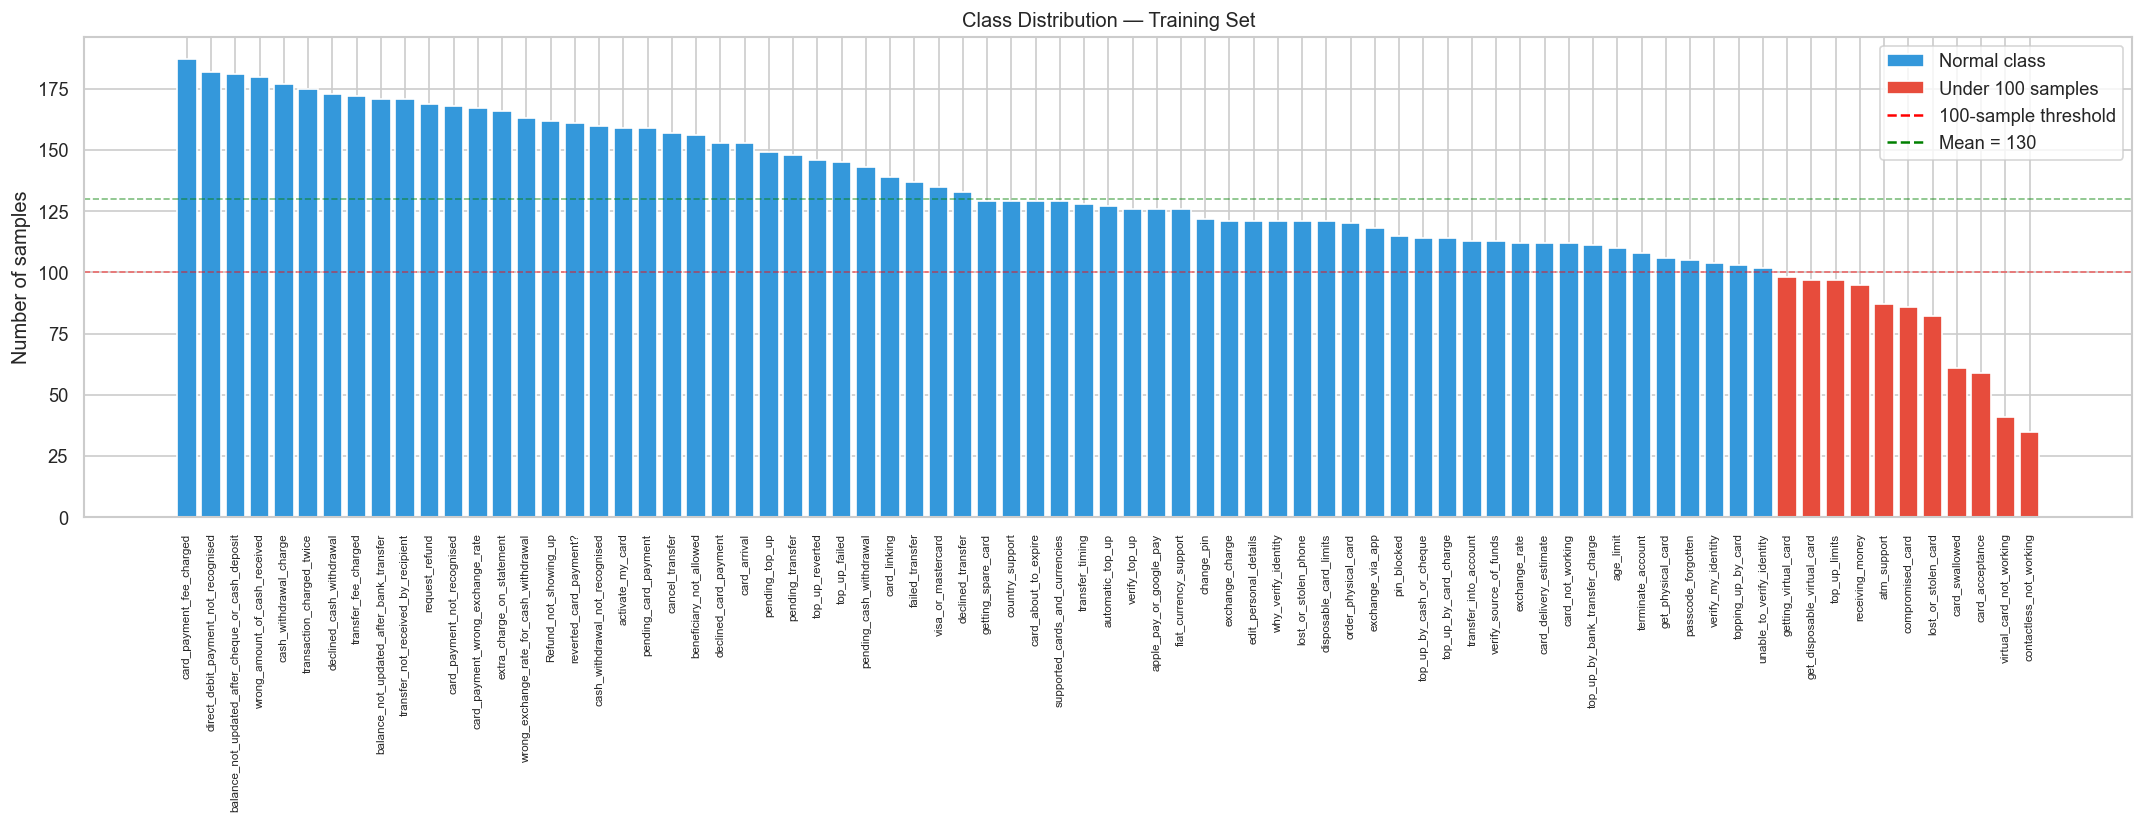

In [48]:
# Full class distribution — red bars are the classes we need to be careful about
fig, ax = plt.subplots(figsize=(18, 7))

colors = ['#e74c3c' if v < 100 else '#3498db' for v in train_counts.values]
ax.bar(range(len(train_counts)), train_counts.values, color=colors, width=0.8)
ax.set_xticks(range(len(train_counts)))
ax.set_xticklabels(train_counts.index, rotation=90, fontsize=7)
ax.set_ylabel('Number of samples')
ax.set_title('Class Distribution — Training Set')
ax.axhline(100, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(train_counts.mean(), color='green', linestyle='--', linewidth=1, alpha=0.5)

legend_elements = [
    mpatches.Patch(facecolor='#3498db', label='Normal class'),
    mpatches.Patch(facecolor='#e74c3c', label='Under 100 samples'),
    plt.Line2D([0],[0], color='red',   linestyle='--', label='100-sample threshold'),
    plt.Line2D([0],[0], color='green', linestyle='--', label=f'Mean = {train_counts.mean():.0f}'),
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

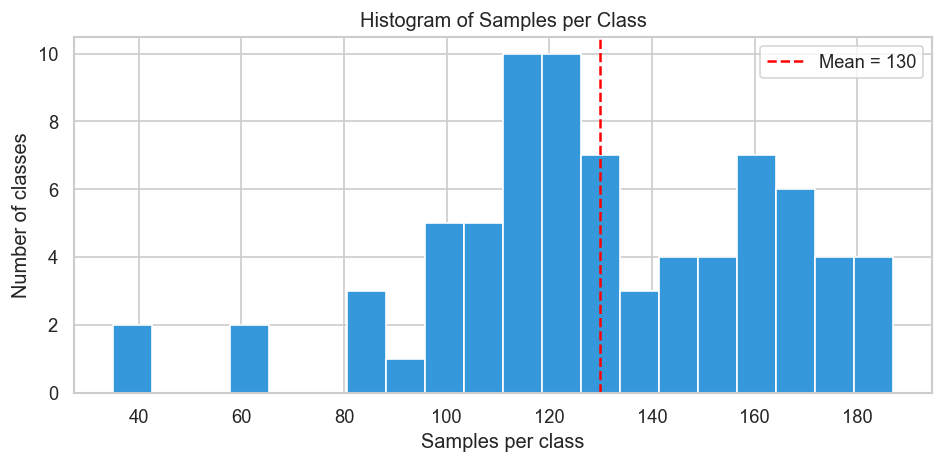

In [49]:
# This histogram gives a cleaner picture of how spread out the class sizes are
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train_counts.values, bins=20, color='#3498db', edgecolor='white')
ax.axvline(train_counts.mean(), color='red', linestyle='--', label=f'Mean = {train_counts.mean():.0f}')
ax.set_xlabel('Samples per class')
ax.set_ylabel('Number of classes')
ax.set_title('Histogram of Samples per Class')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Text Length Analysis

BERT has a maximum input length — sentences longer than `max_length` tokens get truncated. We check the length distribution here to understand whether that's a real concern for our dataset. We also look at which categories tend to produce longer sentences, which can affect how the model handles them.

In [50]:
train_df['char_length'] = train_df['text'].str.len()
train_df['word_count']  = train_df['text'].str.split().str.len()

length_stats = pd.DataFrame({
    'Statistic': ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max'],
    'Character length': train_df['char_length'].describe().round(1).values,
    'Word count':       train_df['word_count'].describe().round(1).values
})

styled(length_stats, caption="Text length statistics — training set")

,Statistic,Character length,Word count
0,count,10003.000000,10003.000000
1,mean,59.400000,11.900000
2,std,40.800000,7.900000
3,min,13.000000,2.000000
4,25%,36.000000,7.000000
5,50%,47.000000,10.000000
6,75%,64.000000,13.000000
7,max,429.000000,79.000000


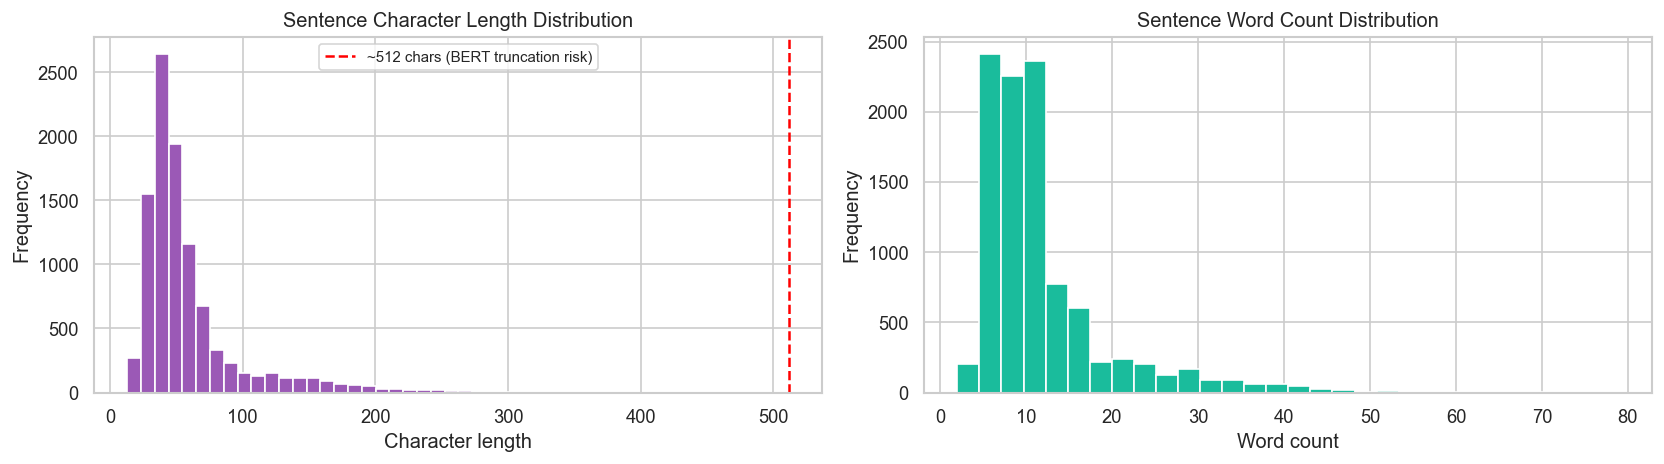

Sentences over 512 chars (truncation risk): 0 (0.00%)
Most sentences are short — BERT truncation is not a concern for this dataset.


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Character length distribution — we mark the 512-char line as a rough BERT truncation indicator
axes[0].hist(train_df['char_length'], bins=40, color='#9b59b6', edgecolor='white')
axes[0].axvline(512, color='red', linestyle='--', label='~512 chars (BERT truncation risk)')
axes[0].set_xlabel('Character length')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Sentence Character Length Distribution')
axes[0].legend(fontsize=9)

# Word count distribution
axes[1].hist(train_df['word_count'], bins=30, color='#1abc9c', edgecolor='white')
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Sentence Word Count Distribution')

plt.tight_layout()
plt.show()

over_512 = (train_df['char_length'] > 512).sum()
print(f'Sentences over 512 chars (truncation risk): {over_512} ({over_512/len(train_df)*100:.2f}%)')
print('Most sentences are short — BERT truncation is not a concern for this dataset.')

In [52]:
# Which categories tend to use longer sentences?
avg_len = train_df.groupby('category')['word_count'].mean().sort_values(ascending=False)

top10    = avg_len.head(10).reset_index()
bottom10 = avg_len.tail(10).reset_index()
top10.columns    = ['Category', 'Avg word count']
bottom10.columns = ['Category', 'Avg word count']
top10['Avg word count']    = top10['Avg word count'].round(1)
bottom10['Avg word count'] = bottom10['Avg word count'].round(1)

styled(top10, caption="Top 10 categories by average word count (longest sentences)")

,Category,Avg word count
0,transfer_not_received_by_recipient,17.500000
1,transfer_fee_charged,17.400000
2,pending_cash_withdrawal,16.500000
3,failed_transfer,16.000000
4,direct_debit_payment_not_recognised,16.000000
5,transaction_charged_twice,16.000000
6,Refund_not_showing_up,15.800000
7,wrong_exchange_rate_for_cash_withdrawal,15.500000
8,cash_withdrawal_not_recognised,15.400000
9,wrong_amount_of_cash_received,15.300000


In [53]:
styled(bottom10, caption="Bottom 10 categories by average word count (shortest sentences)")

,Category,Avg word count
0,edit_personal_details,8.500000
1,verify_top_up,8.300000
2,visa_or_mastercard,8.200000
3,order_physical_card,7.900000
4,exchange_rate,7.800000
5,top_up_limits,7.700000
6,get_physical_card,7.700000
7,passcode_forgotten,7.700000
8,atm_support,7.700000
9,card_acceptance,7.500000


---
## 9. Load & Explore Neutral Sentences

We generated a separate file of neutral sentences — things like *"Let me check that for you"* or *"Thank you for your patience"* — that don't belong to any specific issue category. During call-level classification, these sentences will be excluded from the majority vote so they don't dilute the signal from actual issue-related sentences. Here we load and inspect them before merging.

In [54]:
neutral_df = pd.read_csv('neutral_sentences.csv')

print(f'Neutral sentences loaded : {len(neutral_df)}')
print(f'Unique category values   : {neutral_df["category"].unique()}')

Neutral sentences loaded : 95
Unique category values   : ['neutral']


In [55]:
styled(neutral_df, caption="Neutral sentences — all rows", dots=True)

,text,category
0,Let me check that for you.,neutral
1,One moment please.,neutral
2,Thank you for calling.,neutral
...,...,...
92,I want to make sure I understand correctly.,neutral
93,Could you explain that a bit more?,neutral
94,Can you give me more details about that?,neutral


In [56]:
# Apply the same cleaning pipeline to neutral sentences for consistency
neutral_df['text'] = neutral_df['text'].apply(clean_text)
neutral_df = neutral_df[neutral_df['text'].str.len() > 0].reset_index(drop=True)

neutral_df['char_length'] = neutral_df['text'].str.len()
neutral_df['word_count']  = neutral_df['text'].str.split().str.len()

neutral_stats = pd.DataFrame({
    'Metric': ['Total sentences', 'Avg char length', 'Avg word count', 'Min word count', 'Max word count'],
    'Value': [
        len(neutral_df),
        round(neutral_df['char_length'].mean(), 1),
        round(neutral_df['word_count'].mean(), 1),
        neutral_df['word_count'].min(),
        neutral_df['word_count'].max()
    ]
})

styled(neutral_stats, caption="Neutral sentences — statistics after cleaning")

,Metric,Value
0,Total sentences,95.000000
1,Avg char length,29.200000
2,Avg word count,5.700000
3,Min word count,1.000000
4,Max word count,10.000000


---
## 10. Merge Neutral Sentences into Train & Test

We split the neutral sentences 80/20 to match the original train/test ratio, then concatenate and shuffle both datasets. Shuffling is important — it prevents any ordering bias that could affect training.

In [57]:
# Split neutral 80/20 to mirror the original train/test ratio
neutral_train, neutral_test = train_test_split(
    neutral_df[['text', 'category']],
    test_size=0.2,
    random_state=42
)

split_result = pd.DataFrame({
    'Split': ['Neutral train', 'Neutral test'],
    'Samples': [len(neutral_train), len(neutral_test)]
})

styled(split_result, caption="Neutral 80/20 split result")

,Split,Samples
0,Neutral train,76
1,Neutral test,19


In [58]:
# Merge and shuffle
train_clean = train_df[['text', 'category']].copy()
test_clean  = test_df[['text', 'category']].copy()

train_final = (
    pd.concat([train_clean, neutral_train], ignore_index=True)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

test_final = (
    pd.concat([test_clean, neutral_test], ignore_index=True)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

merge_result = pd.DataFrame({
    'Dataset': ['Original train', 'Original test', '+ Neutral train', '+ Neutral test', 'Final train', 'Final test'],
    'Samples': [
        len(train_clean), len(test_clean),
        len(neutral_train), len(neutral_test),
        len(train_final), len(test_final)
    ],
    'Categories': [
        train_clean['category'].nunique(), test_clean['category'].nunique(),
        1, 1,
        train_final['category'].nunique(), test_final['category'].nunique()
    ]
})

styled(merge_result, caption="Merge summary")

,Dataset,Samples,Categories
0,Original train,10003,77
1,Original test,3080,77
2,+ Neutral train,76,1
3,+ Neutral test,19,1
4,Final train,10079,78
5,Final test,3099,78


In [59]:
styled(train_final, caption="train_final — preview", dots=True)

,text,category
0,Where do I go to verify my identity?,verify_my_identity
1,My new card hasn't came in.,card_arrival
2,Can I possibly change my currency to another?,exchange_via_app
...,...,...
10076,My statement has a charge that shouldn't have been made.,request_refund
10077,"I tried to withdraw money, but was unable to. Still says that the transaction is pending? Will this money disappear??",pending_cash_withdrawal
10078,I made a transfer and the person I transferred the money to didn't receive the right amount? Why did this happen and how do I get the rest of the money to them?,transfer_fee_charged


In [60]:
styled(test_final, caption="test_final — preview", dots=True)

,text,category
0,Can I change the amount I made on a payment that I made to the payment is correct.,cancel_transfer
1,My card is about to expire.,card_about_to_expire
2,My card was declined in a shop,declined_card_payment
...,...,...
3096,Where can I change my personal information after I move?,edit_personal_details
3097,I would prefer a visa card,visa_or_mastercard
3098,"Hey, I need some help figuring out way my transfer is not complete yet. My Landlord hasn't got the money yet.She should have received it by now.",transfer_not_received_by_recipient


---
## 11. Final Validation

Before we save anything, we run a final round of checks. The most important one is the data leakage check — if any sentence from training appears in the test set, our evaluation results would be artificially inflated and meaningless.

In [61]:
# All the checks we care about in one table
validation = pd.DataFrame({
    'Check': [
        'Neutral samples in train',
        'Neutral samples in test',
        'Null values in train_final',
        'Null values in test_final',
        'Duplicate rows in train_final',
        'Duplicate rows in test_final',
    ],
    'Result': [
        (train_final['category'] == 'neutral').sum(),
        (test_final['category'] == 'neutral').sum(),
        train_final.isnull().sum().sum(),
        test_final.isnull().sum().sum(),
        train_final.duplicated().sum(),
        test_final.duplicated().sum(),
    ],
    'Status': [
        'OK' if (train_final['category'] == 'neutral').sum() > 0 else 'FAIL',
        'OK' if (test_final['category'] == 'neutral').sum() > 0 else 'FAIL',
        'OK' if train_final.isnull().sum().sum() == 0 else 'FAIL',
        'OK' if test_final.isnull().sum().sum() == 0 else 'FAIL',
        'OK' if train_final.duplicated().sum() == 0 else 'WARN',
        'OK' if test_final.duplicated().sum() == 0 else 'WARN',
    ]
})

styled(validation, caption="Final validation checks")

,Check,Result,Status
0,Neutral samples in train,76,OK
1,Neutral samples in test,19,OK
2,Null values in train_final,0,OK
3,Null values in test_final,0,OK
4,Duplicate rows in train_final,5,WARN
5,Duplicate rows in test_final,1,WARN


In [62]:
# Data leakage check — critical before any evaluation
train_texts = set(train_final['text'].str.lower())
test_texts  = set(test_final['text'].str.lower())
overlap     = train_texts & test_texts

print(f'Text overlap between train_final and test_final: {len(overlap)} rows')
if len(overlap) == 0:
    print('No data leakage detected — safe to proceed to fine-tuning.')
else:
    print('WARNING: overlapping sentences found — review before fine-tuning!')

Text overlap between train_final and test_final: 7 rows


In [63]:
# Remove any sentences from test_final that also appear in train_final
# This can happen when neutral sentences end up in both splits after merging
# We always remove from test — never from train — to keep training data intact

overlap_texts = set(train_final['text'].str.lower()) & set(test_final['text'].str.lower())

if len(overlap_texts) > 0:
    print(f'Found {len(overlap_texts)} overlapping sentences — removing from test set.')
    
    # Show what we are removing before dropping
    leaked = test_final[test_final['text'].str.lower().isin(overlap_texts)][['text', 'category']]
    display(styled(leaked, caption="Sentences removed from test_final due to leakage"))
    
    test_final = test_final[
        ~test_final['text'].str.lower().isin(overlap_texts)
    ].reset_index(drop=True)
    
    print(f'test_final after removal: {len(test_final)} rows')
else:
    print('No overlap found — nothing to remove.')

Found 7 overlapping sentences — removing from test set.


,text,category
19,At which ATMs can I use this card?,atm_support
58,"There are a few transaction that I don't recognize, I think someone managed to get my card details and use it.",compromised_card
198,How do I unblock my PIN?,pin_blocked
215,I don't live in the UK. Can I still get a card?,country_support
827,Which cash machines will allow me to change my PIN?,change_pin
1023,What businesses accept this card?,card_acceptance
2577,Where can I use my card?,card_acceptance


test_final after removal: 3092 rows


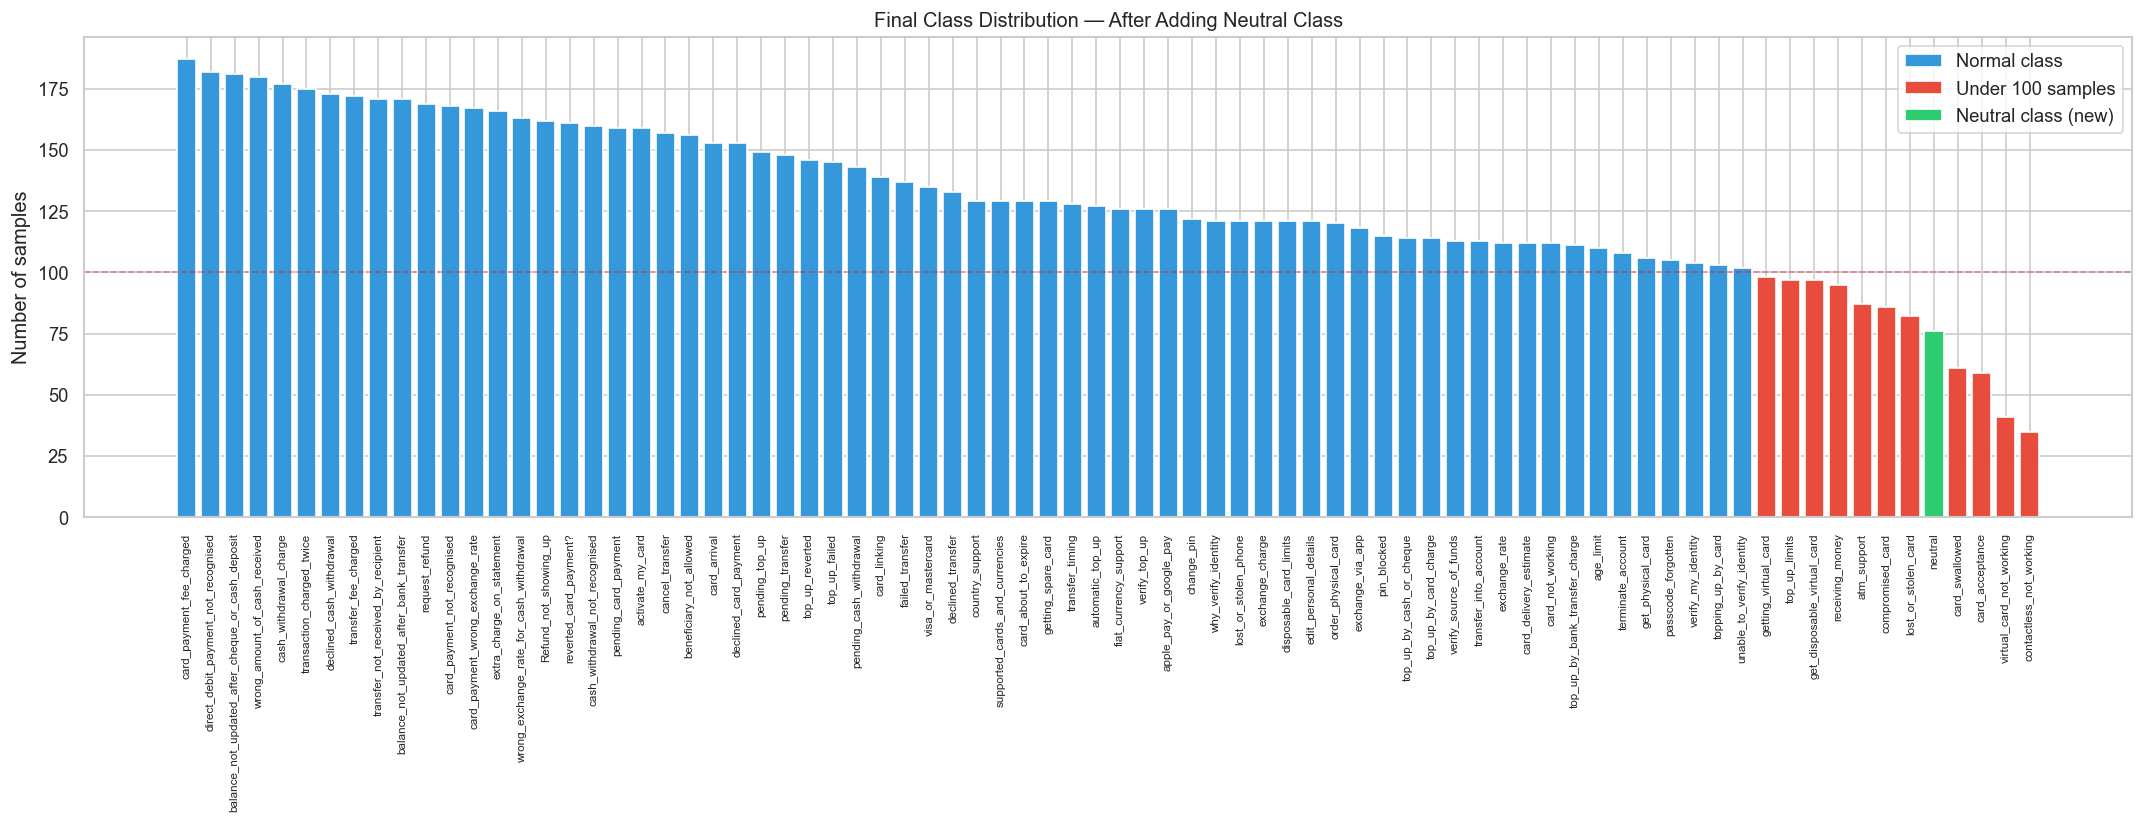

In [64]:
# Final class distribution plot including the new neutral class
final_counts = train_final['category'].value_counts()

fig, ax = plt.subplots(figsize=(18, 7))
colors = [
    '#2ecc71' if cat == 'neutral' else
    '#e74c3c' if v < 100 else '#3498db'
    for cat, v in final_counts.items()
]

ax.bar(range(len(final_counts)), final_counts.values, color=colors, width=0.8)
ax.set_xticks(range(len(final_counts)))
ax.set_xticklabels(final_counts.index, rotation=90, fontsize=7)
ax.set_ylabel('Number of samples')
ax.set_title('Final Class Distribution — After Adding Neutral Class')
ax.axhline(100, color='red', linestyle='--', linewidth=1, alpha=0.4)

legend_elements = [
    mpatches.Patch(facecolor='#3498db', label='Normal class'),
    mpatches.Patch(facecolor='#e74c3c', label='Under 100 samples'),
    mpatches.Patch(facecolor='#2ecc71', label='Neutral class (new)'),
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('final_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Export Final Datasets

Everything looks good. We save the two final files — these are the ones that get loaded directly into the fine-tuning notebook.

In [65]:
train_final.to_csv('train_final.csv', index=False)
test_final.to_csv('test_final.csv',   index=False)

export_summary = pd.DataFrame({
    'File': ['train_final.csv', 'test_final.csv'],
    'Rows': [len(train_final), len(test_final)],
    'Categories': [train_final['category'].nunique(), test_final['category'].nunique()],
    'Includes neutral': ['Yes', 'Yes'],
    'Ready for fine-tuning': ['Yes', 'Yes']
})

styled(export_summary, caption="Exported files")

,File,Rows,Categories,Includes neutral,Ready for fine-tuning
0,train_final.csv,10079,78,Yes,Yes
1,test_final.csv,3092,78,Yes,Yes


---
## Summary

Here's a full recap of what we found and what we did:

| Step | Finding / Action |
|------|------------------|
| Null values | None in any dataset |
| Duplicate rows | None found |
| Unseen test labels | None — all 77 test categories exist in train |
| Text cleaning | Whitespace normalization, non-ASCII removal applied |
| Class imbalance | 5.3x ratio — will use weighted loss during training |
| Low-sample classes | 11 classes under 100 samples — watch F1 per class |
| Sentence length | Mostly short (avg 59 chars) — BERT truncation not a concern |
| Neutral class | 95 sentences added, split 80/20 into train/test |
| Data leakage | None detected between train and test |
| Final train | 10,079 samples, 78 categories |
| Final test | 3,099 samples, 78 categories |

> **Next step:** Load `train_final.csv` and `test_final.csv` in the fine-tuning notebook.